# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [65]:
import numpy as np


x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

alphas = [round(0.015 + 0.001 * i, 6) for i in range(11)]

all_err = {}
for alpha in alphas:
    errors = []
    for i in range(15):

        X_train = np.delete(x, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_test = x[i]
        y_test = y[i]

        I = np.identity(2)
        w = np.linalg.inv(X_train.T * X_train + alpha * I) * X_train.T * y_train

        y_pred = X_test * w
        error = (y_test - y_pred) ** 2
        errors.append(error.item())

    all_err[alpha] = np.mean(errors)

min_e = min(all_err.values())
rel_errors = [[k, round(all_err[k] - min_e, 7), all_err[k]] for k in all_err.keys()]

for k, e, ae in rel_errors:
    print("alpha =", str(k).rjust(6), "error =", str(round(ae, 6)).ljust(7), "(delta = ", str(round(e, 6)).ljust(7), ")")

alpha =  0.015 error = 462.312662 (delta =  0.803473 )
alpha =  0.016 error = 462.048967 (delta =  0.539778 )
alpha =  0.017 error = 461.840874 (delta =  0.331685 )
alpha =  0.018 error = 461.685505 (delta =  0.176316 )
alpha =  0.019 error = 461.580132 (delta =  0.070943 )
alpha =   0.02 error = 461.522175 (delta =  0.012986 )
alpha =  0.021 error = 461.509189 (delta =  0.0     )
alpha =  0.022 error = 461.538856 (delta =  0.029667 )
alpha =  0.023 error = 461.608979 (delta =  0.09979 )
alpha =  0.024 error = 461.717475 (delta =  0.208286 )
alpha =  0.025 error = 461.862368 (delta =  0.353179 )


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [66]:
def sgd(X, y, alpha=0.1, lr=0.0001, epochs=10):
    n, d = X.shape
    w = np.zeros((d, 1))

    for epoch in range(epochs):
        for i in range(n):
            xi = X[i:i+1].T
            yi = y[i, 0]

            y_pred = (w.T @ xi).item()
            error = y_pred - yi
            grad = error * xi

            for j in range(1, d):
                grad[j] += alpha * np.sign(w[j])

            w = w - lr * grad
    return w

In [67]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = (x - np.mean(x)) / np.std(x)
x = np.c_[np.ones((15,1)), x]

alpha = 0.1

# SGD
w_sgd = sgd(x, y, alpha=alpha, lr=0.002, epochs=10000)
print("SGD weights:", w_sgd.ravel())

# sklearn
from sklearn.linear_model import Lasso
model = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
model.fit(x, y.ravel())
print("sklearn weights:", model.coef_)

SGD weights: [102.51537048  26.1458595 ]
sklearn weights: [102.36666667  26.23725365]


## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

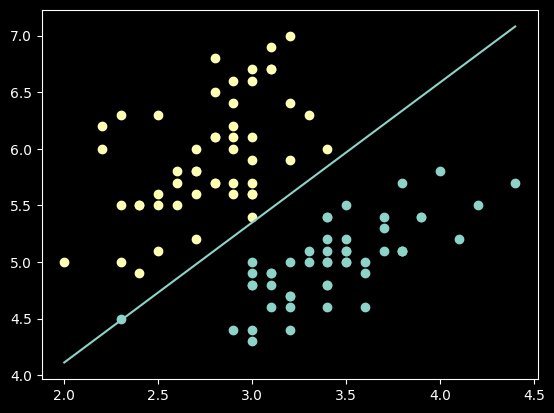

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df.head()

x = iris_df[['sepal width (cm)', 'sepal length (cm)']].values
y = iris_data.target

dataset_size = np.size(x)

# mean_x, mean_y = np.mean(x), np.mean(y)
#
# SS_xy = np.sum(y * x) - dataset_size * mean_y * mean_x
# SS_xx = np.sum(x * x) - dataset_size * mean_x * mean_x
#
# a = SS_xy / SS_xx
# b = mean_y - a * mean_x
#
# y_pred = a * x + b

x = x[y != 2]
y = y[y != 2]
x0 = x[y == 0]
x1 = x[y == 1]

m0 = np.mean(x0, axis=0)
m1 = np.mean(x1, axis=0)
S0 = (x0 - m0).T @ (x0 - m0)
S1 = (x1 - m1).T @ (x1 - m1)
Sw = S0 + S1

w = np.linalg.inv(Sw) @ (m1 - m0)

proj = x @ w
threshold = 0.5 * (m0 @ w + m1 @ w)

y_pred = (proj >= threshold).astype(int)


plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1])
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1])
x_vals = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)
plt.plot(x_vals, (threshold - w[0]*x_vals)/w[1])
plt.show()